In [3]:
%pip install  scipy
%pip install xarray
%pip install pandas
%pip install numpy
import xarray as xr
import pandas as pd
import numpy as np
from scipy.special import erf

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy.special import erf

# monthly temperature
ERA5_DIR = r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\ERA5\extracted"
ds_t = xr.open_dataset(ERA5_DIR + r"\data_stream-moda_stepType-avgua.nc")
t2m_c = ds_t["t2m"] - 273.15
tdim = "valid_time" if "valid_time" in t2m_c.dims else "time"

# geopotential to elevation conversion
zg = xr.open_dataset("../Data/Raw/ERA5/era5_geopotential_alps.nc")
z_era5_m = zg["z"].squeeze() / 9.80665

# glaciers
df = pd.read_csv("../Data/Processed/stage2_model_ready.csv")
lon  = xr.DataArray(df["CenLon"].values, dims="g")
lat  = xr.DataArray(df["CenLat"].values, dims="g")
zmed = xr.DataArray(df["Zmed"].values,  dims="g")

# extract + lapse-correct
t_at = t2m_c.sel(longitude=lon, latitude=lat, method="nearest")
z_at = z_era5_m.sel(longitude=lon, latitude=lat, method="nearest")
t_corr = t_at - 0.0065 * (zmed - z_at)

# Calov-Greve PDD
sigma = 4.0
days = t_corr[tdim].dt.days_in_month
pdd = days * (sigma/np.sqrt(2*np.pi)*np.exp(-t_corr**2/(2*sigma**2))
              + t_corr/2*(1 + erf(t_corr/(sigma*np.sqrt(2)))))
# annual APDD
apdd_yearly = pdd.groupby(f"{tdim}.year").sum(tdim)
df["apdd"] = apdd_yearly.sel(year=slice(2000, 2019)).mean("year").values

print(df["apdd"].describe())
df.to_csv("../Data/Processed/stage2_model_ready.csv", index=False)
print("Saved to stage3_with_APDD.csv")

count    3927.000000
mean      609.952705
std       220.341867
min        29.438572
25%       472.410043
50%       590.885370
75%       719.322844
max      2432.416118
Name: apdd, dtype: float64
Saved to stage3_with_APDD.csv


In [5]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [6]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# loading model table
df = pd.read_csv("../Data/Processed/stage2_model_ready.csv")

# re-attaching O2 Region for spatial grouping (from the RGI v6 shapefile)
rgi6 = gpd.read_file(r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\RGI\nsidc0770_11.rgi60.CentralEurope\11_rgi60_CentralEurope.shp")[["RGIId", "O2Region"]]
df = df.merge(rgi6, on="RGIId", how="left")

# features and target
features = ["Area", "Zmed", "Slope", "Lmax", "northness", "eastness",
            "t_jja_corr", "p_annual", "srad_jja", "apdd"]
X = df[features]
y = df["dmdtda"]
groups = df["O2Region"]

# model::
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                           random_state=42, n_jobs=-1)

# spatial cross-validated predictions (leaving-one-subregion-out)
gkf = GroupKFold(n_splits=groups.nunique())
y_pred = cross_val_predict(rf, X, y, groups=groups, cv=gkf, n_jobs=-1)

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"Spatial CV  R² = {r2:.3f}   RMSE = {rmse:.3f} m w.e./yr")

# fits on all data for feature importances
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
print("\nFeature importances:\n", imp[::-1])

Spatial CV  R² = -0.336   RMSE = 0.410 m w.e./yr

Feature importances:
 Area          0.168939
Slope         0.146160
Zmed          0.111240
Lmax          0.101026
eastness      0.085320
srad_jja      0.084276
northness     0.080516
apdd          0.075910
p_annual      0.073874
t_jja_corr    0.072738
dtype: float64


In [7]:
for col in ["t_jja_corr", "apdd", "p_annual", "srad_jja"]:
    print(f"{col}: {df[col].nunique()} unique values, "
          f"range {df[col].min():.1f} to {df[col].max():.1f}")

print("\nSubregion counts:")
print(df["O2Region"].value_counts())

t_jja_corr: 3733 unique values, range -4.7 to 14.3
apdd: 3733 unique values, range 29.4 to 2432.4
p_annual: 120 unique values, range 710.5 to 2253.5
srad_jja: 120 unique values, range 18146978.0 to 24697412.0

Subregion counts:
O2Region
1    3892
2      35
Name: count, dtype: int64


In [9]:
import pandas as pd, numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# load the table WITH APDD (correct filename)
df = pd.read_csv("C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Processed\stage2_model_ready.csv")

# features and target
features = ["Area", "Zmed", "Slope", "Lmax", "northness", "eastness",
            "t_jja_corr", "p_annual", "srad_jja", "apdd"]
df = df.dropna(subset=features + ["dmdtda"])
X = df[features]
y = df["dmdtda"]

# model
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3,
                           random_state=42, n_jobs=-1)

# random 5-fold CV (inherent predictive skill)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_random = cross_val_predict(rf, X, y, cv=kf, n_jobs=-1)
r2_r  = r2_score(y, y_pred_random)
rmse_r = np.sqrt(mean_squared_error(y, y_pred_random))
print(f"Random 5-fold CV:   R² = {r2_r:.3f}   RMSE = {rmse_r:.3f} m w.e./yr")

# spatial block CV (transferability test)
df = df.reset_index(drop=True)
df["block"] = (pd.qcut(df["CenLon"], 5, labels=False) * 2
               + pd.qcut(df["CenLat"], 2, labels=False))
n_blocks = df["block"].nunique()
gkf = GroupKFold(n_splits=n_blocks)
y_pred_spatial = cross_val_predict(rf, X, y, groups=df["block"], cv=gkf, n_jobs=-1)
r2_s  = r2_score(y, y_pred_spatial)
rmse_s = np.sqrt(mean_squared_error(y, y_pred_spatial))
print(f"Spatial block CV ({n_blocks} blocks):  R² = {r2_s:.3f}   RMSE = {rmse_s:.3f} m w.e./yr")

# feature importances (fit on all data)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances:\n", imp)

Random 5-fold CV:   R² = 0.205   RMSE = 0.316 m w.e./yr
Spatial block CV (9 blocks):  R² = 0.144   RMSE = 0.328 m w.e./yr

Feature importances:
 Area          0.168939
Slope         0.146160
Zmed          0.111240
Lmax          0.101026
eastness      0.085320
srad_jja      0.084276
northness     0.080516
apdd          0.075910
p_annual      0.073874
t_jja_corr    0.072738
dtype: float64


In [ ]:
import pandas as pd

df["block"] = (pd.qcut(df["CenLon"], 5, labels=False) * 2
               + pd.qcut(df["CenLat"], 2, labels=False))

from sklearn.model_selection import GroupKFold
n_blocks = df["block"].nunique()
gkf = GroupKFold(n_splits=n_blocks)
y_pred_spatial = cross_val_predict(rf, X, y, groups=df["block"], cv=gkf, n_jobs=-1)

r2_s = r2_score(y, y_pred_spatial)
rmse_s = np.sqrt(mean_squared_error(y, y_pred_spatial))
print(f"Spatial block CV ({n_blocks} blocks):  R² = {r2_s:.3f}   RMSE = {rmse_s:.3f}")

In [4]:
import os
import pandas as pd
folder = r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\WGMS\wgms-amce-2025-02b\wgms-amce-2025-02b\individual-glacier"
meta = pd.read_csv(os.path.join(folder, "CEU_CentralEurope_metadata.csv"))
print("\nMetadata shape:", meta.shape)
print("Metadata columns:", meta.columns.tolist())
print(meta.head(3).to_string())


Metadata shape: (3927, 18)
Metadata columns: ['RGIId', 'REGION', 'CenLon', 'CenLat', 'Area', 'WGMS_ID', 'N_gla_anom_used', 'ID_gla_anom_used', 'min_dist_gla_anom', 'max_dist_gla_anom', 'mean_dist_gla_anom', 'std_dist_gla_anom', 'period_reg_obs', 'N_gla_anom_neighbour_reg', 'ID_gla_anom_neighbour_reg', 'period_neighbour_reg_obs', 'N_geo_obs', 'period_geo_obs']
            RGIId REGION   CenLon   CenLat   Area   WGMS_ID N_gla_anom_used                                                                                                                                                                                                                                                  ID_gla_anom_used min_dist_gla_anom max_dist_gla_anom mean_dist_gla_anom std_dist_gla_anom period_reg_obs N_gla_anom_neighbour_reg ID_gla_anom_neighbour_reg period_neighbour_reg_obs N_geo_obs         period_geo_obs
0  RGI60-11.00001    CEU  13.5987  47.4949  0.122  134185.0            48.0  [535, 545, 1305, 547, 566, 57

In [5]:
import os, pandas as pd

folder = r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\WGMS\wgms-amce-2025-02b\wgms-amce-2025-02b\individual-glacier"

d = pd.read_csv(os.path.join(folder, "CEU_gla_MEAN-CAL-mass-change-series_obs_unobs.csv"))

# confirming the year range available
year_cols = [c for c in d.columns if c.isdigit()]
print("Years available:", year_cols[0], "to", year_cols[-1])

# getting 2022 plus a baseline for comparison
obs = d[["RGIId", "WGMS_ID"]].copy()
obs["mb_2022"] = d["2022"]
obs["mb_baseline_2000_2019"] = d[[str(y) for y in range(2000, 2020)]].mean(axis=1)
obs["mb_anom_2022"] = obs["mb_2022"] - obs["mb_baseline_2000_2019"]

print(obs[["mb_2022", "mb_baseline_2000_2019", "mb_anom_2022"]].describe())

# merging into table
df = pd.read_csv("../Data/Processed/stage3_with_APDD.csv")
df = df.merge(obs, left_on="RGIId", right_on="RGIId", how="left")
print("\nMerged:", df["mb_2022"].notna().sum(), "of", len(df), "glaciers have 2022 data")

df.to_csv("../Data/Processed/stage4_with_2022.csv", index=False)

Years available: 1915 to 2024
           mb_2022  mb_baseline_2000_2019  mb_anom_2022
count  3927.000000            3927.000000   3927.000000
mean     -2.946551              -0.694540     -2.252010
std       0.453800               0.365419      0.256660
min      -5.493615              -3.535432     -3.446671
25%      -3.181472              -0.873102     -2.376321
50%      -3.033352              -0.756399     -2.241928
75%      -2.683705              -0.492716     -2.122725
max       0.384344               2.711741     -1.063102

Merged: 3927 of 3927 glaciers have 2022 data


In [6]:
print(df[["apdd_anom_2022", "mb_anom_2022", "Zmed", "Area"]].corr())

                apdd_anom_2022  mb_anom_2022      Zmed      Area
apdd_anom_2022        1.000000     -0.076805 -0.491377 -0.014807
mb_anom_2022         -0.076805      1.000000 -0.028229  0.009275
Zmed                 -0.491377     -0.028229  1.000000  0.064980
Area                 -0.014807      0.009275  0.064980  1.000000


In [7]:
print(df[["mb_anom_2022", "mb_baseline_2000_2019"]].corr().iloc[0,1])

0.03480983161278962


In [11]:
import pandas as pd

WGMS = r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\WGMS\DOI-WGMS-FoG-2026-02-10 (1)\data"

mb = pd.read_csv(WGMS + r"\mass_balance.csv")
gl = pd.read_csv(WGMS + r"\glacier.csv")

# attach RGI v6 ids to the mass-balance records
m = mb.merge(gl[["id", "rgi60_ids"]], left_on="glacier_id", right_on="id", how="left")

# Alpine glaciers, 2022 only
alpine_2022 = m[(m["rgi60_ids"].astype(str).str.startswith("RGI60-11")) &
                (m["year"] == 2022)].copy()

print(len(alpine_2022), "Alpine glaciers with 2022 field measurements")
print(alpine_2022["annual_balance"].describe())

alpine_2022.to_csv("../Data/Processed/wgms_alpine_2022.csv", index=False)
print("Saved.")

50 Alpine glaciers with 2022 field measurements
count    48.000000
mean     -3.182000
std       0.701664
min      -4.677000
25%      -3.630000
50%      -3.250000
75%      -2.800000
max      -0.308000
Name: annual_balance, dtype: float64
Saved.


In [12]:
wgms = pd.read_csv("../Data/Processed/wgms_alpine_2022.csv")
val = df.merge(wgms[["rgi60_ids", "annual_balance"]],
               left_on="RGIId", right_on="rgi60_ids", how="inner")
print(len(val), "matched")
print(val[["annual_balance", "apdd_anom_2022", "Zmed", "Area", "Slope"]].corr()["annual_balance"])

50 matched
annual_balance    1.000000
apdd_anom_2022   -0.494484
Zmed              0.215098
Area              0.115654
Slope             0.146887
Name: annual_balance, dtype: float64


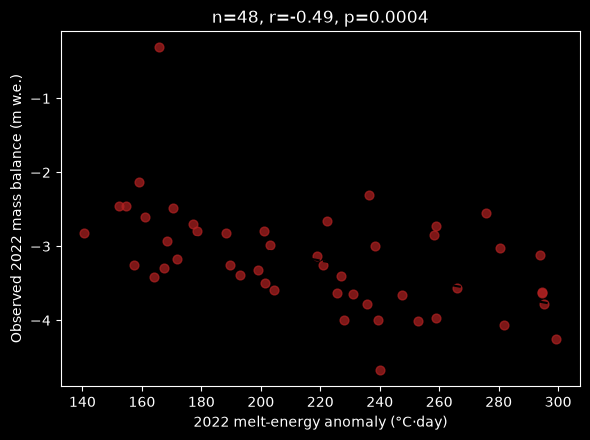

r = -0.494, r² = 0.245, p = 0.00035
Slope: -0.00753 m w.e. per °C·day


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

v = val.dropna(subset=["annual_balance", "apdd_anom_2022"])
slope, intercept, r, p, se = stats.linregress(v["apdd_anom_2022"], v["annual_balance"])

plt.figure(figsize=(6,4.5))
plt.scatter(v["apdd_anom_2022"], v["annual_balance"], s=40, alpha=0.7, color="firebrick")
x = np.linspace(v["apdd_anom_2022"].min(), v["apdd_anom_2022"].max(), 50)
plt.plot(x, intercept + slope*x, "k--")
plt.xlabel("2022 melt-energy anomaly (°C·day)")
plt.ylabel("Observed 2022 mass balance (m w.e.)")
plt.title(f"n={len(v)}, r={r:.2f}, p={p:.4f}")
plt.tight_layout()
plt.savefig("../Figures/wgms_2022_vs_apdd.png", dpi=200)
plt.show()

print(f"r = {r:.3f}, r² = {r**2:.3f}, p = {p:.5f}")
print(f"Slope: {slope:.5f} m w.e. per °C·day")

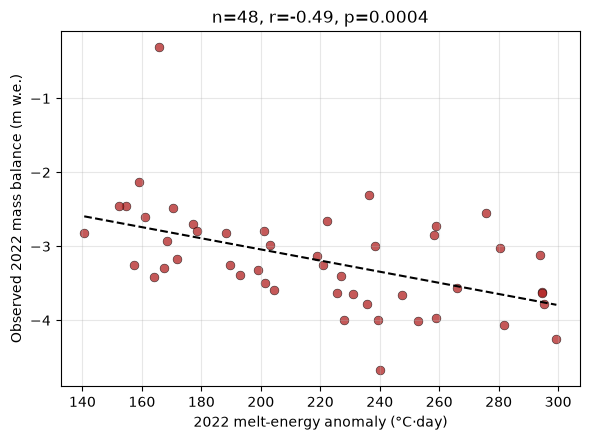

In [14]:
import matplotlib.pyplot as plt

plt.style.use("default")

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor="white")
ax.set_facecolor("white")

ax.scatter(v["apdd_anom_2022"], v["annual_balance"], s=40, alpha=0.75,
           color="firebrick", edgecolor="black", linewidth=0.4)
x = np.linspace(v["apdd_anom_2022"].min(), v["apdd_anom_2022"].max(), 50)
ax.plot(x, intercept + slope*x, "k--", linewidth=1.5)

ax.set_xlabel("2022 melt-energy anomaly (°C·day)")
ax.set_ylabel("Observed 2022 mass balance (m w.e.)")
ax.set_title(f"n={len(v)}, r={r:.2f}, p={p:.4f}")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../Figures/wgms_2022_vs_apdd.png", dpi=200,
            facecolor="white", bbox_inches="tight")
plt.show()

In [15]:
print(v.nlargest(3, "annual_balance")[["RGIId", "annual_balance", "apdd_anom_2022", "Zmed", "Area", "Slope"]])

             RGIId  annual_balance  apdd_anom_2022  Zmed    Area  Slope
43  RGI60-11.03241          -0.308      165.810691  2791   0.033   18.7
2   RGI60-11.00106          -2.128      159.129936  2984  17.774   15.9
35  RGI60-11.02766          -2.310      236.376602  3272  16.697   17.3
